# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdelrahmanmohamed05/FlyRank-AI/blob/main/work/notebooks/w06_validation_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Two paper findings + my methodology questions

*Pick two findings from the FlyRank research paper. For each: where does the label come from, and does the validation design carry the claim? Constructive tone.*

In [1]:
paper_findings = [
    ("Weighted CTR is higher for higher-position tiers; the report gives 0.420% for Top 3 versus 0.050% for Deep.",
     "How are CTR and position tiers weighted and defined? I would check that the same population and time window are used across tiers and that high-impression pages do not dominate the comparison."),
    ("The report says headline findings prioritize direct aggregate comparisons, while ML pages are exploratory appendix material.",
     "For any predictive claim, what are the feature window, label window, split design, and leakage checks? Disclosing these would make the boundary between observed evidence and exploratory prediction clearer.")
]
for i, (finding, question) in enumerate(paper_findings, 1):
    print(f"Finding {i}: {finding}")
    print(f"Methodology question: {question}\n")
print("Constructive review: these are methodology questions, not grades of the paper.")

Finding 1: Weighted CTR is higher for higher-position tiers; the report gives 0.420% for Top 3 versus 0.050% for Deep.
Methodology question: How are CTR and position tiers weighted and defined? I would check that the same population and time window are used across tiers and that high-impression pages do not dominate the comparison.

Finding 2: The report says headline findings prioritize direct aggregate comparisons, while ML pages are exploratory appendix material.
Methodology question: For any predictive claim, what are the feature window, label window, split design, and leakage checks? Disclosing these would make the boundary between observed evidence and exploratory prediction clearer.

Constructive review: these are methodology questions, not grades of the paper.


## 2. My model under an honest split (before/after)

*Re-run your Week-5 model under a grouped or time-aware split. Show both numbers.*

In [2]:
import os
import getpass
import warnings
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# Hugging Face authentication
# -----------------------------
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Enter your Hugging Face READ token: ")

con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

# -----------------------------
# Dataset  (FIX: the repo is FlyRank/internship-warehouse;
# the old id "flyrank-ai/flyrank-search-intelligence-release-2026-06" gave HTTP 404)
# -----------------------------
REL = "hf://datasets/FlyRank/internship-warehouse"
FACT_DIR = f"{REL}/fact_content_daily_performance"

print("Dataset configured:")
print(FACT_DIR)

Dataset configured:
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance


In [3]:
# ---------- helpers: read only the months we need (the fact table is month-partitioned) ----------
REQUIRED = {"client_hash_id", "content_hash_id", "report_date",
            "gsc_impressions", "gsc_clicks", "gsc_sum_position"}
_SRC_CACHE = {}

def _lit(files):
    return "[" + ", ".join(f"'{f}'" for f in files) + "]"

def get_source(start, end):
    """SQL literal for the parquet files covering [start, end]. Targets month=YYYY-MM folders,
    falls back to the full glob (slower) if that layout is not found."""
    key = (start, end)
    if key in _SRC_CACHE:
        return _SRC_CACHE[key]
    months = pd.period_range(pd.Timestamp(start), pd.Timestamp(end), freq="M")
    targeted = _lit([f"{FACT_DIR}/month={m}/*.parquet" for m in months])
    fallback = _lit([f"{FACT_DIR}/**/*.parquet"])
    for cand in (targeted, fallback):
        try:
            con.execute(f"DESCRIBE SELECT * FROM read_parquet({cand})")
            _SRC_CACHE[key] = cand
            return cand
        except Exception as e:
            last = e
    raise RuntimeError(f"Could not read the fact table. Check token access to the gated dataset. Last error: {last}")

# ---------- schema check ----------
cols = set(con.execute(f"DESCRIBE SELECT * FROM read_parquet({get_source('2026-02-01','2026-02-28')})").df()["column_name"])
missing = REQUIRED - cols
assert not missing, f"Missing columns in fact table: {missing}"
HAS_AVAIL = "gsc_data_available" in cols
print("Schema OK. gsc_data_available present:", HAS_AVAIL)

Schema OK. gsc_data_available present: True


In [4]:
def build_window(f_start, f_end, l_start, l_end):
    """One row per page. Features come ONLY from [f_start, f_end); outcome from [l_start, l_end)."""
    assert pd.Timestamp(f_end) <= pd.Timestamp(l_start), "feature window must end before the outcome window starts"
    mid = (pd.Timestamp(f_start) + pd.Timedelta(days=14)).date()
    avail = "AND gsc_data_available IS TRUE" if HAS_AVAIL else ""
    fw = f"report_date >= DATE '{f_start}' AND report_date < DATE '{f_end}'"
    lw = f"report_date >= DATE '{l_start}' AND report_date < DATE '{l_end}'"
    q = f"""
    SELECT * FROM (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) FILTER (WHERE {fw})                    AS imp_f,
            SUM(gsc_clicks)      FILTER (WHERE {fw})                    AS clk_f,
            SUM(gsc_sum_position) FILTER (WHERE {fw})                   AS sumpos_f,
            COUNT(DISTINCT report_date) FILTER (WHERE {fw} AND gsc_impressions > 0) AS days_active_f,
            SUM(gsc_clicks) FILTER (WHERE report_date >= DATE '{f_start}' AND report_date < DATE '{mid}')  AS clk_early_f,
            SUM(gsc_clicks) FILTER (WHERE report_date >= DATE '{mid}'     AND report_date < DATE '{f_end}') AS clk_late_f,
            SUM(gsc_impressions) FILTER (WHERE {lw})                    AS imp_l,
            SUM(gsc_clicks)      FILTER (WHERE {lw})                    AS clk_l
        FROM read_parquet({get_source(f_start, l_end)})
        WHERE report_date >= DATE '{f_start}' AND report_date < DATE '{l_end}' {avail}
        GROUP BY client_hash_id, content_hash_id
    )
    WHERE imp_f >= 100 AND clk_f >= 3 AND imp_l >= 100
    """
    return con.execute(q).df()

FEATURES = ["log_imp_f", "log_clk_f", "ctr_f", "pos_f", "days_active_f", "trend_f"]

def make_frame(f_start, f_end, l_start, l_end):
    df = build_window(f_start, f_end, l_start, l_end)
    f_days = (pd.Timestamp(f_end) - pd.Timestamp(f_start)).days
    l_days = (pd.Timestamp(l_end) - pd.Timestamp(l_start)).days
    for c in ["clk_early_f", "clk_late_f"]:
        df[c] = df[c].fillna(0)
    df["ctr_f"]    = df["clk_f"] / df["imp_f"]
    df["pos_f"]    = df["sumpos_f"] / df["imp_f"]        # impression-weighted average position
    df["log_imp_f"] = np.log1p(df["imp_f"])
    df["log_clk_f"] = np.log1p(df["clk_f"])
    df["trend_f"]  = np.log((df["clk_late_f"] + 1) / (df["clk_early_f"] + 1))   # inside the feature window only
    # label: daily click rate in the outcome month < 70% of the feature month's daily rate
    df["y"] = ((df["clk_l"] / l_days) < 0.7 * (df["clk_f"] / f_days)).astype(int)
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES + ["y"]).reset_index(drop=True)
    return df

CUR  = ("2026-02-01", "2026-03-01", "2026-03-01", "2026-04-01")   # features Feb -> outcome Mar
PREV = ("2026-01-01", "2026-02-01", "2026-02-01", "2026-03-01")   # features Jan -> outcome Feb

MAX_ROWS = 300_000   # keeps Colab fast; rows are sampled at random (clients stay whole in expectation)
df = make_frame(*CUR)
print("Feb->Mar pages:", len(df), "| decline rate (prevalence):", round(df["y"].mean(), 3),
      "| clients:", df["client_hash_id"].nunique())
if len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print("Sampled down to", len(df), "rows")
display(df[FEATURES + ["y"]].describe().T.round(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feb->Mar pages: 29274 | decline rate (prevalence): 0.338 | clients: 30


,count,mean,std,min,25%,50%,75%,max
log_imp_f,29274.0,7.903,1.077,4.615,7.206,7.860,8.597,12.028
log_clk_f,29274.0,2.410,0.900,1.386,1.609,2.197,2.890,8.105
ctr_f,29274.0,0.005,0.005,0.000,0.002,0.004,0.006,0.182
pos_f,29274.0,7.724,6.973,0.040,3.431,5.399,8.678,69.695
days_active_f,29274.0,25.767,5.842,1.000,28.000,28.000,28.000,28.000
trend_f,29274.0,0.328,0.961,-4.796,-0.288,0.201,0.693,6.617
y,29274.0,0.338,0.473,0.000,0.000,0.000,1.000,1.000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Time-aware train rows (Jan->Feb): 22212


,split,AUC (mean),AUC (fold std),Avg precision
0,Before: random rows,0.676,0.011,0.506
1,After A: grouped by client,0.646,0.064,0.480
2,"After B: time-aware (Jan->Feb train, Feb->Mar ...",0.634,NaN,0.463


Prevalence (AP of a no-skill model): 0.338
Naive one-feature baseline (log Feb clicks, direction-free) AUC: 0.581


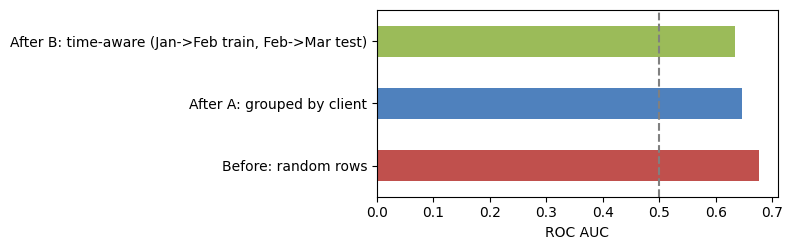

Per-fold AUC, grouped by client: [0.646, 0.613, 0.563, 0.733, 0.677]


In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

def make_model():
    return HistGradientBoostingClassifier(max_depth=4, learning_rate=0.1, max_iter=150, random_state=42)

X, y, groups = df[FEATURES], df["y"], df["client_hash_id"]

def cv_eval(splitter, use_groups=False, labels=None):
    yy = y if labels is None else labels
    oof = np.zeros(len(df)); rows = []
    split_iter = splitter.split(X, yy, groups) if use_groups else splitter.split(X, yy)
    for tr, te in split_iter:
        m = make_model().fit(X.iloc[tr], yy.iloc[tr])
        p = m.predict_proba(X.iloc[te])[:, 1]
        oof[te] = p
        rows.append((roc_auc_score(yy.iloc[te], p), average_precision_score(yy.iloc[te], p)))
    return oof, pd.DataFrame(rows, columns=["auc", "ap"])

# BEFORE: random rows
oof_rand, res_rand = cv_eval(StratifiedKFold(5, shuffle=True, random_state=42))
# AFTER (A): grouped by client
oof_grp, res_grp = cv_eval(GroupKFold(5), use_groups=True)

# AFTER (B): time-aware  (train Jan->Feb, test Feb->Mar)
try:
    prev = make_frame(*PREV)
    if len(prev) > MAX_ROWS: prev = prev.sample(MAX_ROWS, random_state=42)
    m_t = make_model().fit(prev[FEATURES], prev["y"])
    p_t = m_t.predict_proba(df[FEATURES])[:, 1]
    time_auc, time_ap = roc_auc_score(df["y"], p_t), average_precision_score(df["y"], p_t)
    print("Time-aware train rows (Jan->Feb):", len(prev))
except Exception as e:
    time_auc = time_ap = np.nan
    print("Time-aware split skipped:", e)

prev_rate = df["y"].mean()
a_ = roc_auc_score(df["y"], df["log_clk_f"])
base_auc = max(a_, 1 - a_)   # naive one-feature baseline (direction-free): busier pages behave differently (regression to the mean)

summary = pd.DataFrame({
    "split": ["Before: random rows", "After A: grouped by client", "After B: time-aware (Jan->Feb train, Feb->Mar test)"],
    "AUC (mean)": [res_rand.auc.mean(), res_grp.auc.mean(), time_auc],
    "AUC (fold std)": [res_rand.auc.std(), res_grp.auc.std(), np.nan],
    "Avg precision": [res_rand.ap.mean(), res_grp.ap.mean(), time_ap],
}).round(3)
display(summary)
print(f"Prevalence (AP of a no-skill model): {prev_rate:.3f}")
print(f"Naive one-feature baseline (log Feb clicks, direction-free) AUC: {base_auc:.3f}")

ax = summary.set_index("split")["AUC (mean)"].plot.barh(figsize=(8, 2.6), color=["#c0504d", "#4f81bd", "#9bbb59"])
ax.axvline(0.5, color="gray", ls="--"); ax.set_xlabel("ROC AUC"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print("Per-fold AUC, grouped by client:", res_grp.auc.round(3).tolist())

### What changed, in simple words

The random split lets the model see other pages from the *same client* while training. If clients differ a lot (different traffic patterns, different decline rates), the model can learn "which client" instead of "which page pattern", and the random-split number looks better than it should. The grouped and time-aware numbers are the honest ones, because they mimic the real use case: score **new clients** or **next month**. All numbers are **measured** on this snapshot and are **directional**; they are not a promise for future data.

## 3. Leakage audit

*The same hunt from Week 3, on your final feature set.*

In [6]:
# 1) Window discipline: features must come only from the feature month
assert pd.Timestamp(CUR[1]) <= pd.Timestamp(CUR[2]), "feature window overlaps outcome window"
print("PASS  feature window ends", CUR[1], "and outcome window starts", CUR[2])

# 2) No outcome columns and no ID columns in the feature list
bad = [c for c in FEATURES if c.endswith("_l") or c in ("y", "client_hash_id", "content_hash_id")]
print("PASS  no outcome/ID columns in features" if not bad else f"FLAG  suspicious features: {bad}")

# 3) Single-feature AUC: a single feature that separates classes almost perfectly is a red flag
rows = []
for f in FEATURES:
    a = roc_auc_score(df["y"], df[f])
    rows.append((f, round(a, 3), "FLAG" if (a > 0.9 or a < 0.1) else "ok"))
display(pd.DataFrame(rows, columns=["feature", "single-feature AUC", "status"]))

# 4) Shuffled-label sanity check under the grouped split: AUC should be about 0.5
rng = np.random.default_rng(0)
y_shuf = pd.Series(rng.permutation(df["y"].values), index=df.index)
_, res_shuf = cv_eval(GroupKFold(5), use_groups=True, labels=y_shuf)
print(f"Shuffled-label AUC (grouped): {res_shuf.auc.mean():.3f}  ->",
      "PASS (about 0.5)" if abs(res_shuf.auc.mean() - 0.5) < 0.05 else "FLAG (check the pipeline)")

# 5) Why the random split is optimistic: client overlap + client concentration
tr_idx, te_idx = next(StratifiedKFold(5, shuffle=True, random_state=42).split(X, y))
share_seen = df.loc[te_idx, "client_hash_id"].isin(set(df.loc[tr_idx, "client_hash_id"])).mean()
print(f"Random split: {share_seen:.1%} of test pages belong to a client that is also in training.")
grp_tr, grp_te = next(GroupKFold(5).split(X, y, groups))
print("Grouped split: client overlap between train and test =",
      len(set(groups.iloc[grp_tr]) & set(groups.iloc[grp_te])))

client_stats = df.groupby("client_hash_id").agg(pages=("y", "size"), decline_rate=("y", "mean"))
print(f"Top-5 clients hold {client_stats.pages.nlargest(5).sum() / len(df):.1%} of pages; "
      f"client-level decline rate ranges {client_stats.decline_rate.min():.2f} to {client_stats.decline_rate.max():.2f} "
      f"(std {client_stats.decline_rate.std():.2f}).")

# 6) Same page in both time windows (time-aware split still shares pages across train and test)
try:
    same_pages = len(set(zip(prev.client_hash_id, prev.content_hash_id)) & set(zip(df.client_hash_id, df.content_hash_id)))
    print(f"Time-aware split: {same_pages} pages appear in both train and test windows (different months) -> a stricter test would also group by client.")
except NameError:
    pass

PASS  feature window ends 2026-03-01 and outcome window starts 2026-03-01
PASS  no outcome/ID columns in features


,feature,single-feature AUC,status
0,log_imp_f,0.430,ok
1,log_clk_f,0.419,ok
2,ctr_f,0.506,ok
3,pos_f,0.502,ok
4,days_active_f,0.560,ok
5,trend_f,0.420,ok


Shuffled-label AUC (grouped): 0.498  -> PASS (about 0.5)
Random split: 100.0% of test pages belong to a client that is also in training.
Grouped split: client overlap between train and test = 0
Top-5 clients hold 81.1% of pages; client-level decline rate ranges 0.00 to 0.80 (std 0.20).
Time-aware split: 18531 pages appear in both train and test windows (different months) -> a stricter test would also group by client.


### Audit notes

- Features use **only** the feature month; `client_hash_id` and `content_hash_id` are used for grouping, never as inputs.
- The label needs March impressions ≥ 100 (a page must still be visible). That is **survivorship**: pages that vanished completely are not in the data, so decline is probably *under*-counted. I state this as a limit, not a fix.
- Regression to the mean is a real risk here: pages with an unusually good month tend to look worse next month. The naive one-feature baseline above shows how much of the score this alone can explain.

In [7]:
err = df[FEATURES + ["y"]].copy()
err["score"] = oof_grp
show = FEATURES + ["score", "y"]

print("Most confident FALSE POSITIVES (model said 'will decline', it did not):")
display(err[err.y == 0].nlargest(6, "score")[show].round(3))

print("Most confident FALSE NEGATIVES (model said 'safe', it declined):")
display(err[err.y == 1].nsmallest(6, "score")[show].round(3))

# Where does it work worst? AUC by position tier of the feature month
err["tier"] = pd.cut(err["pos_f"], [0, 3, 10, 20, 1000], labels=["Top 3", "4-10", "11-20", "Deep"])
by_tier = err.groupby("tier", observed=True).apply(
    lambda g: pd.Series({"pages": len(g), "decline_rate": g.y.mean(),
                         "AUC": roc_auc_score(g.y, g.score) if g.y.nunique() == 2 else np.nan}))
display(by_tier.round(3))

Most confident FALSE POSITIVES (model said 'will decline', it did not):


,log_imp_f,log_clk_f,ctr_f,pos_f,days_active_f,trend_f,score,y
29204,5.505,1.386,0.012,28.706,28,-1.386,0.897,0
5031,5.628,1.386,0.011,23.332,28,-0.405,0.864,0
18312,5.389,1.609,0.018,11.532,22,-0.693,0.863,0
5016,5.613,1.386,0.011,32.923,28,-0.405,0.859,0
23616,9.290,4.585,0.009,2.552,28,-3.466,0.858,0
13993,5.505,1.386,0.012,17.702,28,0.405,0.853,0


Most confident FALSE NEGATIVES (model said 'safe', it declined):


,log_imp_f,log_clk_f,ctr_f,pos_f,days_active_f,trend_f,score,y
29265,6.953,2.565,0.011,3.488,4,2.565,0.007,1
27169,6.319,1.792,0.009,3.951,4,1.792,0.009,1
29267,7.497,2.639,0.007,3.094,4,2.639,0.009,1
29270,6.356,1.946,0.010,1.553,4,1.946,0.010,1
29183,5.943,1.792,0.013,8.821,6,1.792,0.012,1
29268,6.789,1.946,0.007,2.829,4,1.946,0.012,1


,pages,decline_rate,AUC
tier,,,
Top 3,5591.0,0.338,0.646
4-10,17482.0,0.339,0.636
11-20,4032.0,0.344,0.669
Deep,2169.0,0.320,0.625


**Reading the failures (directional):** look at the tables above for a pattern — for example, whether false negatives are pages with a flat or rising trend that suddenly fell (nothing in February could show that), and whether some position tiers score much worse than others. Those are the cases where a human should not lean on the score.

## 4. Claim rewrite

*Take your own boldest sentence and rewrite it in safe language: observed, measured, directional, decision-support.*

In [8]:
bold = "My model predicts which pages will lose traffic next month with high accuracy."

safe = (
    f"On a snapshot of pages with at least 100 impressions in the feature month, a gradient-boosting model "
    f"reached a measured AUC of {res_grp.auc.mean():.2f} (client-grouped 5-fold; random-row split gave {res_rand.auc.mean():.2f}) "
    + (f"and {time_auc:.2f} when trained on Jan->Feb and tested on Feb->Mar. " if not np.isnan(time_auc) else ". ")
    + f"A one-feature baseline (Feb clicks) reached {base_auc:.2f}. "
    "This is a directional, exploratory result on observed Search Console data, not a causal claim and not a forecast guarantee. "
    "It can be used as decision-support to help decide which pages to review first, alongside human judgment."
)

print("BEFORE (too strong):\n", bold, "\n")
print("AFTER (safe language):\n", safe)

BEFORE (too strong):
 My model predicts which pages will lose traffic next month with high accuracy. 

AFTER (safe language):
 On a snapshot of pages with at least 100 impressions in the feature month, a gradient-boosting model reached a measured AUC of 0.65 (client-grouped 5-fold; random-row split gave 0.68) and 0.63 when trained on Jan->Feb and tested on Feb->Mar. A one-feature baseline (Feb clicks) reached 0.58. This is a directional, exploratory result on observed Search Console data, not a causal claim and not a forecast guarantee. It can be used as decision-support to help decide which pages to review first, alongside human judgment.


### Why each word changed

| Original | Rewrite | Reason |
|---|---|---|
| "predicts" | "measured AUC of …" | Report the number and the split, not a verb that sounds like certainty |
| "high accuracy" | compared with baseline and random-split number | "High" is not evidence; the baseline and the honest split give context |
| "will lose traffic" | "observed … decline label" | The label is my own definition on observed data, not a real-world guarantee |
| (none) | "directional, exploratory, decision-support" | States the limit: no causal claim, human stays in the loop |

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.